<a href="https://colab.research.google.com/github/likhithaj21/ML-Student-Placement-Predictor/blob/main/ML_Student_Placement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sns
%matplotlib inline

In [7]:
df = pd.read_csv('student_placement_dataset.csv')

df.head()

,tenth_percent,twelfth_percent,degree_gpa,aptitude_score,programming_skill,communication_skill,internships,projects,placement
0,93,87,8.63,7,9,8,2,2,1
1,84,88,8.56,9,7,9,1,3,1
2,83,95,8.97,7,9,9,1,2,1
3,92,89,9.51,7,10,10,3,2,1
4,97,97,9.16,10,8,10,2,3,1


In [8]:
df.shape

(500, 9)

In [9]:
df.isnull().any()

,0
tenth_percent,False
twelfth_percent,False
degree_gpa,False
aptitude_score,False
programming_skill,False
communication_skill,False
internships,False
projects,False
placement,False


In [10]:
df = df.rename(columns={
'tenth_percent':'tenthMarks',
'twelfth_percent':'twelfthMarks',
'degree_gpa':'degreeCGPA',
'aptitude_score':'aptitudeScore',
'programming_skill':'programmingSkill',
'communication_skill':'communicationSkill',
'internships':'internshipCount',
'projects':'projectCount',
'placement':'placementStatus'
})

df.head(3)

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount,placementStatus
0,93,87,8.63,7,9,8,2,2,1
1,84,88,8.56,9,7,9,1,3,1
2,83,95,8.97,7,9,9,1,2,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tenthMarks          500 non-null    int64  
 1   twelfthMarks        500 non-null    int64  
 2   degreeCGPA          500 non-null    float64
 3   aptitudeScore       500 non-null    int64  
 4   programmingSkill    500 non-null    int64  
 5   communicationSkill  500 non-null    int64  
 6   internshipCount     500 non-null    int64  
 7   projectCount        500 non-null    int64  
 8   placementStatus     500 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 35.3 KB


In [13]:
df.dtypes

,0
tenthMarks,int64
twelfthMarks,int64
degreeCGPA,float64
aptitudeScore,int64
programmingSkill,int64
communicationSkill,int64
internshipCount,int64
projectCount,int64
placementStatus,int64


In [14]:
df.shape

(500, 9)

In [15]:
placement_rate = df.placementStatus.value_counts() / len(df)

placement_rate

,count
placementStatus,
0,0.7
1,0.3


In [16]:
df.describe()

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount,placementStatus
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,75.560000,75.132000,8.280100,6.448000,6.468000,6.52000,1.590000,2.472000,0.300000
std,17.918945,17.501863,1.209833,2.783306,2.840619,2.94056,1.015856,1.449627,0.458717
min,40.000000,40.000000,6.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000
25%,61.000000,60.000000,7.207500,4.000000,4.000000,4.00000,1.000000,2.000000,0.000000
50%,81.000000,80.000000,8.575000,7.000000,7.000000,8.00000,2.000000,2.000000,0.000000
75%,91.000000,90.000000,9.340000,9.000000,9.000000,9.00000,2.000000,3.000000,1.000000
max,100.000000,100.000000,10.000000,10.000000,10.000000,10.00000,3.000000,5.000000,1.000000


In [17]:
# Display mean summary of students (Placed vs Not Placed)

placement_summary = df.groupby('placementStatus')

placement_summary.mean()

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount
placementStatus,,,,,,,,
0,69.557143,69.040000,7.856429,5.588571,5.540000,5.422857,1.434286,2.448571
1,89.566667,89.346667,9.268667,8.453333,8.633333,9.080000,1.953333,2.526667


In [18]:
placement_summary.std()

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount
placementStatus,,,,,,,,
0,18.013077,17.289333,1.187094,2.829822,2.844056,2.841272,1.057093,1.701655
1,5.759634,5.924567,0.442400,1.184841,1.155185,0.790209,0.805490,0.500961


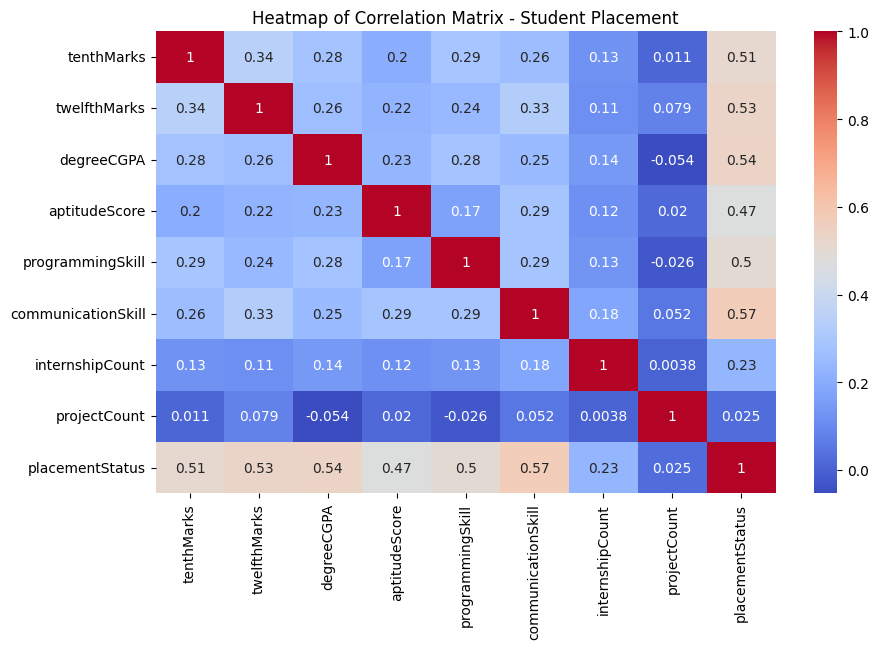

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount,placementStatus
tenthMarks,1.000000,0.342142,0.276671,0.203823,0.289137,0.256013,0.126363,0.011020,0.512234
twelfthMarks,0.342142,1.000000,0.260179,0.222703,0.244479,0.325245,0.114526,0.078502,0.532229
degreeCGPA,0.276671,0.260179,1.000000,0.234522,0.280487,0.248127,0.140035,-0.053561,0.535460
aptitudeScore,0.203823,0.222703,0.234522,1.000000,0.168600,0.286607,0.117543,0.020003,0.472141
programmingSkill,0.289137,0.244479,0.280487,0.168600,1.000000,0.285095,0.129130,-0.025525,0.499526
communicationSkill,0.256013,0.325245,0.248127,0.286607,0.285095,1.000000,0.180195,0.051845,0.570501
internshipCount,0.126363,0.114526,0.140035,0.117543,0.129130,0.180195,1.000000,0.003756,0.234379
projectCount,0.011020,0.078502,-0.053561,0.020003,-0.025525,0.051845,0.003756,1.000000,0.024712
placementStatus,0.512234,0.532229,0.535460,0.472141,0.499526,0.570501,0.234379,0.024712,1.000000


In [19]:
# Create correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    xticklabels=corr.columns.values,
    yticklabels=corr.columns.values,
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap of Correlation Matrix - Student Placement")

plt.show()

corr

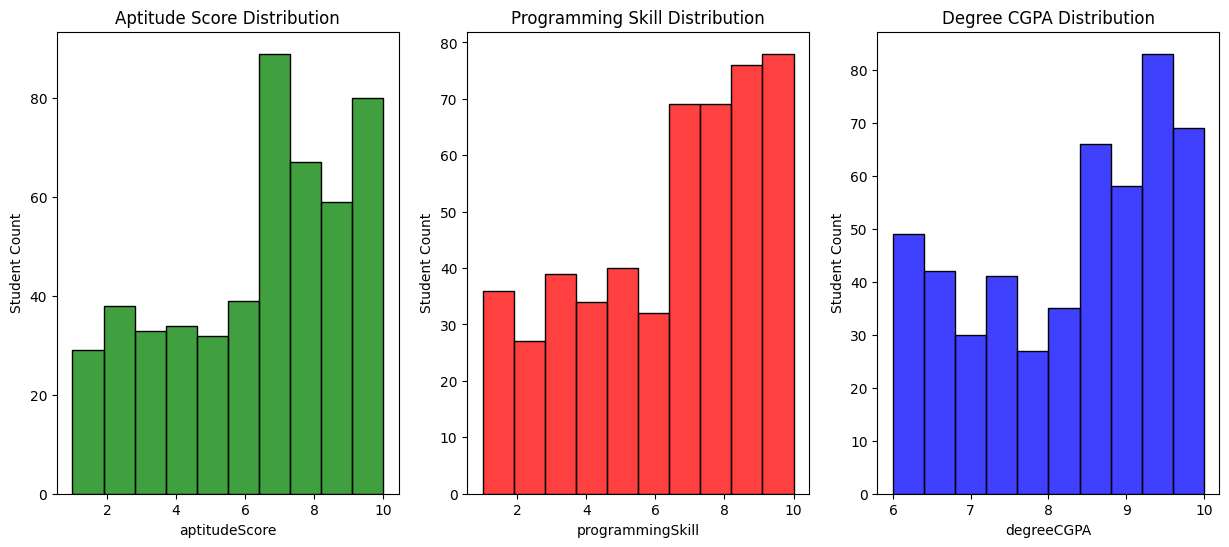

In [20]:
# Plot the distribution of Student Aptitude, Programming Skill, and Degree CGPA

# Set up the matplotlib figure
f, axes = plt.subplots(ncols=3, figsize=(15, 6))

# Graph Aptitude Score
sns.histplot(df.aptitudeScore, kde=False, color="g", ax=axes[0])
axes[0].set_title('Aptitude Score Distribution')
axes[0].set_ylabel('Student Count')

# Graph Programming Skill
sns.histplot(df.programmingSkill, kde=False, color="r", ax=axes[1])
axes[1].set_title('Programming Skill Distribution')
axes[1].set_ylabel('Student Count')

# Graph Degree CGPA
sns.histplot(df.degreeCGPA, kde=False, color="b", ax=axes[2])
axes[2].set_title('Degree CGPA Distribution')
axes[2].set_ylabel('Student Count')

plt.show()

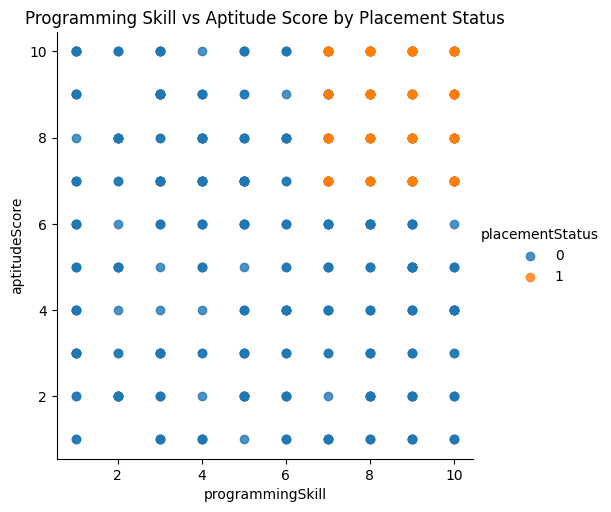

In [21]:
sns.lmplot(
    x='programmingSkill',
    y='aptitudeScore',
    data=df,
    fit_reg=False,   # No regression line
    hue='placementStatus'
)

plt.title("Programming Skill vs Aptitude Score by Placement Status")

plt.show()

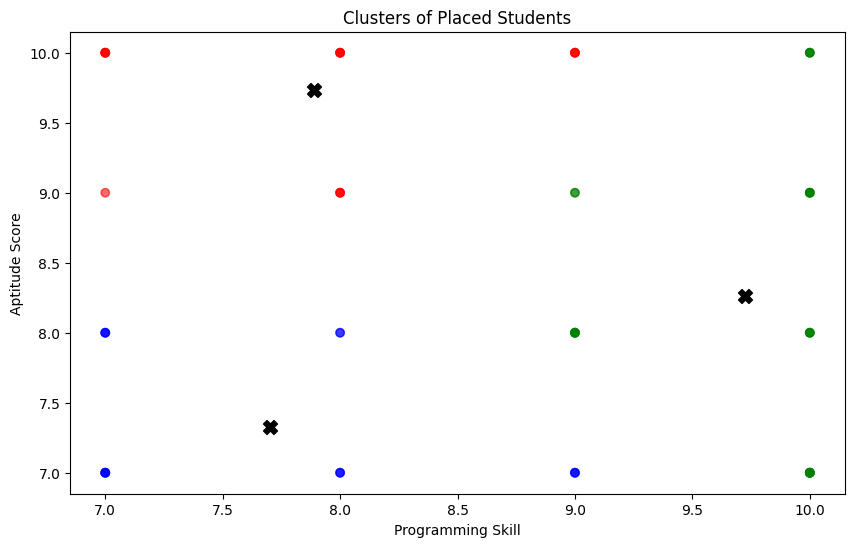

In [22]:
# Import KMeans Model
from sklearn.cluster import KMeans

# Create clusters of Placed Students
kmeans = KMeans(n_clusters=3, random_state=2)

kmeans.fit(df[df.placementStatus==1][["programmingSkill","aptitudeScore"]])

# Assign colors to clusters
kmeans_colors = ['green' if c == 0 else 'blue' if c == 2 else 'red' for c in kmeans.labels_]

# Plot clusters
fig = plt.figure(figsize=(10,6))

plt.scatter(
    x="programmingSkill",
    y="aptitudeScore",
    data=df[df.placementStatus==1],
    alpha=0.25,
    color=kmeans_colors
)

plt.xlabel("Programming Skill")
plt.ylabel("Aptitude Score")

# Cluster centers
plt.scatter(
    x=kmeans.cluster_centers_[:,0],
    y=kmeans.cluster_centers_[:,1],
    color="black",
    marker="X",
    s=100
)

plt.title("Clusters of Placed Students")

plt.show()

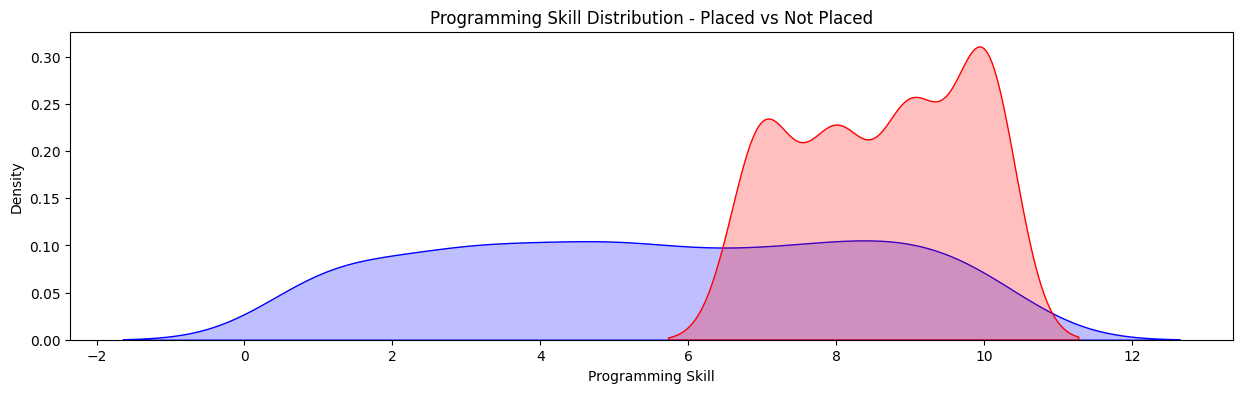

In [23]:
# KDE Plot: Programming Skill Distribution (Placed vs Not Placed)

fig = plt.figure(figsize=(15,4))

ax = sns.kdeplot(
    df.loc[(df['placementStatus'] == 0),'programmingSkill'],
    color='b',
    fill=True,
    label='Not Placed'
)

ax = sns.kdeplot(
    df.loc[(df['placementStatus'] == 1),'programmingSkill'],
    color='r',
    fill=True,
    label='Placed'
)

plt.title('Programming Skill Distribution - Placed vs Not Placed')

plt.xlabel("Programming Skill")
plt.ylabel("Density")

plt.show()

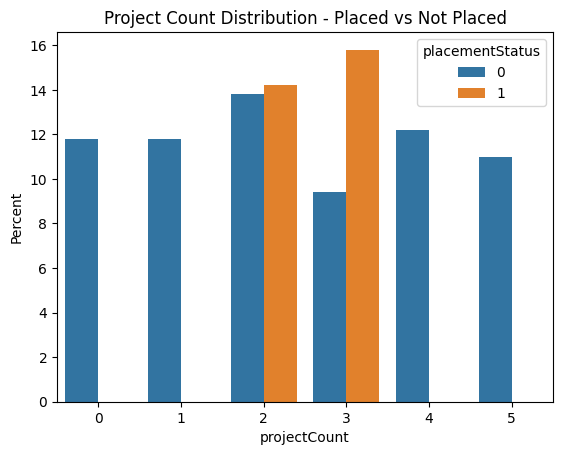

In [24]:
# Bar plot: Project Count vs Placement Status

ax = sns.barplot(
    x="projectCount",
    y="projectCount",
    hue="placementStatus",
    data=df,
    estimator=lambda x: len(x) / len(df) * 100
)

ax.set(ylabel="Percent")

plt.title("Project Count Distribution - Placed vs Not Placed")

plt.show()

In [26]:
# Students who are placed
placed_students = df[df['placementStatus'] == 1]

placed_students = pd.DataFrame(
    placed_students.internshipCount.value_counts()
).reset_index()

# Total students by internship count
total_students = pd.DataFrame(
    df.internshipCount.value_counts()
).reset_index()

# Merge both
placement_merge = pd.merge(
    placed_students,
    total_students,
    how='inner',
    on='internshipCount'
)

# Rename columns
placement_merge = placement_merge.rename(
    columns={
        "count_x": "placed",
        "count_y": "total"
    }
)

placement_merge

,internshipCount,placed,total
0,2,53,150
1,1,52,153
2,3,45,114


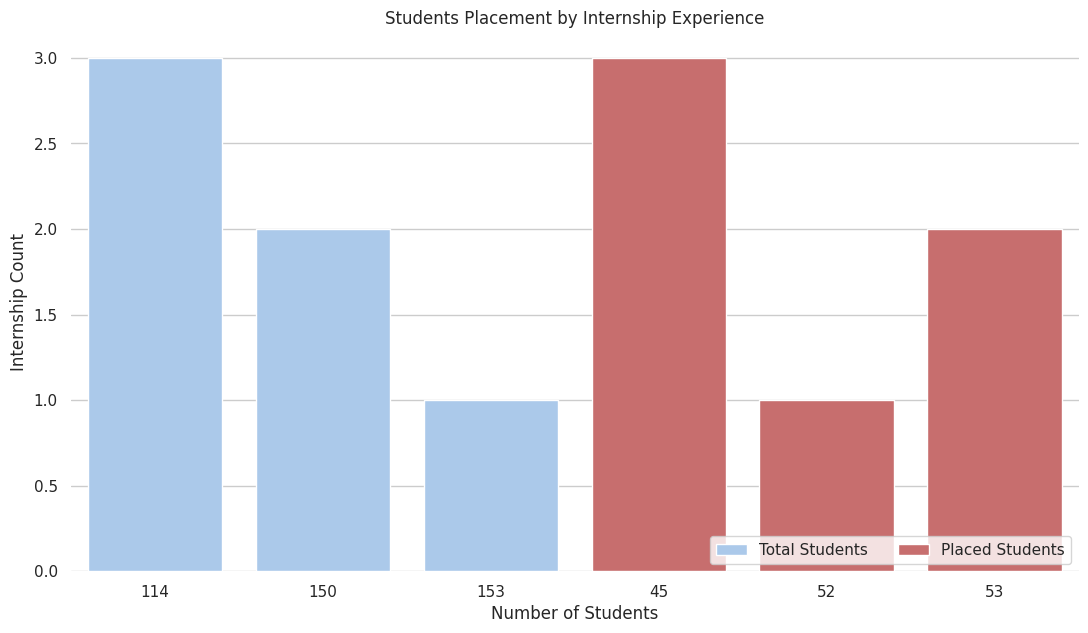

In [27]:
sns.set(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(13,7))

# Plot total students by internship count
sns.set_color_codes("pastel")
sns.barplot(
    x="total",
    y="internshipCount",
    data=placement_merge,
    label="Total Students",
    color="b"
)

# Plot placed students
sns.set_color_codes("muted")
sns.barplot(
    x="placed",
    y="internshipCount",
    data=placement_merge,
    label="Placed Students",
    color="r"
)

# Legend and labels
ax.legend(ncol=2, loc="lower right", frameon=True)

ax.set(
    ylabel="Internship Count",
    title="Students Placement by Internship Experience",
    xlabel="Number of Students"
)

sns.despine(left=True, bottom=True)

plt.show()

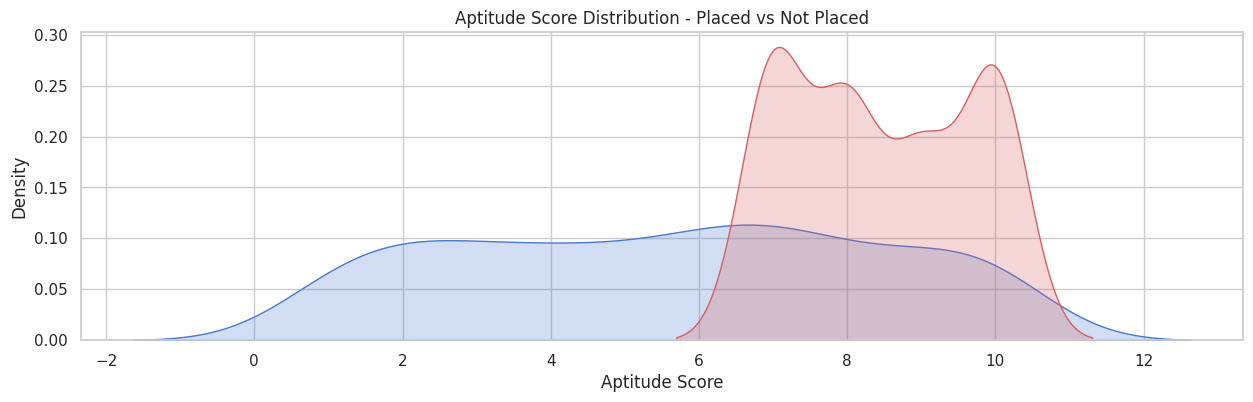

In [28]:
# KDE Plot: Aptitude Score Distribution (Placed vs Not Placed)

fig = plt.figure(figsize=(15,4))

ax = sns.kdeplot(
    df.loc[(df['placementStatus'] == 0), 'aptitudeScore'],
    color='b',
    fill=True,
    label='Not Placed'
)

ax = sns.kdeplot(
    df.loc[(df['placementStatus'] == 1), 'aptitudeScore'],
    color='r',
    fill=True,
    label='Placed'
)

ax.set(xlabel='Aptitude Score', ylabel='Density')

plt.title('Aptitude Score Distribution - Placed vs Not Placed')

plt.show()

In [29]:
# Define categorical and numerical variables

cat_var = ['placementStatus']   # target variable

num_var = [
'tenthMarks',
'twelfthMarks',
'degreeCGPA',
'aptitudeScore',
'programmingSkill',
'communicationSkill',
'internshipCount',
'projectCount'
]

# Convert categorical variables
categorical_df = pd.get_dummies(df[cat_var], drop_first=True)

# Select numerical variables
numerical_df = df[num_var]

# Combine both datasets
new_df = pd.concat([categorical_df, numerical_df], axis=1)

new_df.head()

,placementStatus,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount
0,1,93,87,8.63,7,9,8,2,2
1,1,84,88,8.56,9,7,9,1,3
2,1,83,95,8.97,7,9,9,1,2
3,1,92,89,9.51,7,10,10,3,2
4,1,97,97,9.16,10,8,10,2,3


In [30]:
df.placementStatus.value_counts(1)

,proportion
placementStatus,
0,0.7
1,0.3


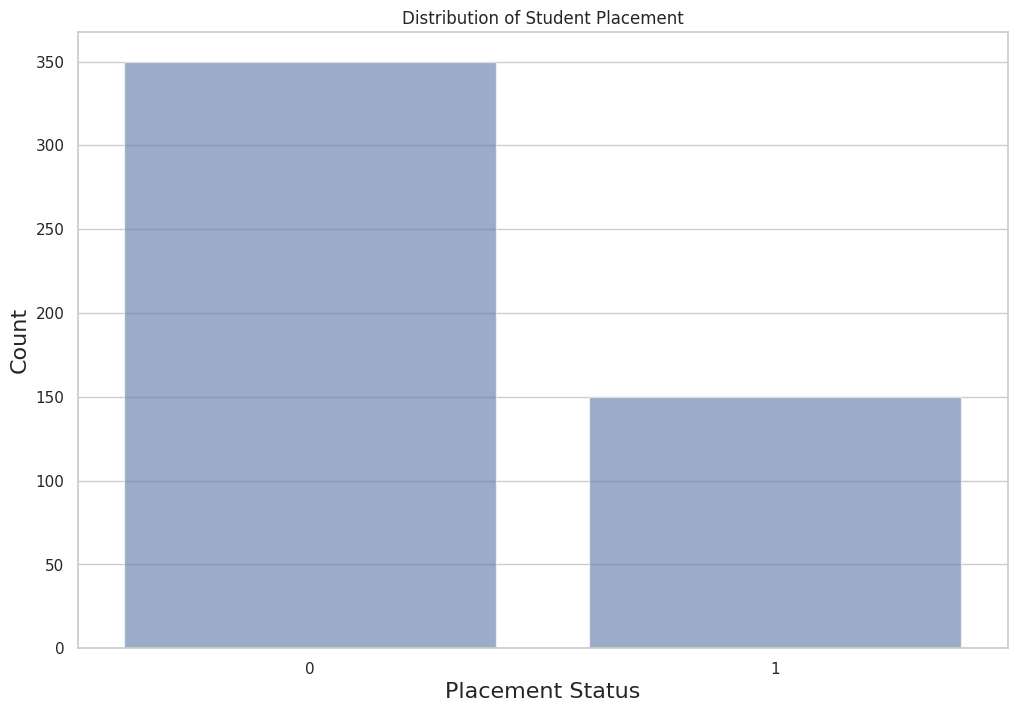

In [31]:
plt.figure(figsize=(12,8))

placement = df.placementStatus.value_counts()

sns.barplot(
    y=placement.values,
    x=placement.index,
    alpha=0.6
)

plt.title('Distribution of Student Placement')
plt.xlabel('Placement Status', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, precision_recall_curve

X = new_df.iloc[:,1:]
y = new_df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=123, stratify=y)

In [33]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE


# Upsample minority class (Placed Students)

X_train_u, y_train_u = resample(
    X_train[y_train == 1],
    y_train[y_train == 1],
    replace=True,
    n_samples=X_train[y_train == 0].shape[0],
    random_state=1
)

X_train_u = np.concatenate((X_train[y_train == 0], X_train_u))
y_train_u = np.concatenate((y_train[y_train == 0], y_train_u))




sm = SMOTE(random_state=12, sampling_strategy=1.0)

x_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)



X_train_d, y_train_d = resample(
    X_train[y_train == 0],
    y_train[y_train == 0],
    replace=True,
    n_samples=X_train[y_train == 1].shape[0],
    random_state=1
)

X_train_d = np.concatenate((X_train[y_train == 1], X_train_d))
y_train_d = np.concatenate((y_train[y_train == 1], y_train_d))



print("Original shape:", X_train.shape, y_train.shape)
print("Upsampled shape:", X_train_u.shape, y_train_u.shape)
print("SMOTE sample shape:", x_train_sm.shape, y_train_sm.shape)
print("Downsampled shape:", X_train_d.shape, y_train_d.shape)

Original shape: (400, 8) (400,)
Upsampled shape: (560, 8) (560,)
SMOTE sample shape: (560, 8) (560,)
Downsampled shape: (240, 8) (240,)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# Create training sets
methods_data = {
    "Original": (X_train, y_train),
    "Upsampled": (X_train_u, y_train_u),
    "SMOTE": (x_train_sm, y_train_sm),
    "Downsampled": (X_train_d, y_train_d)
}


# Apply 5-Fold Cross Validation using Logistic Regression
for method in methods_data.keys():

    lr_results = cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        methods_data[method][0],
        methods_data[method][1],
        cv=5,
        scoring='f1'
    )

    print(f"F1 Score for {method} dataset:")
    print(lr_results.mean())

F1 Score for Original dataset:
0.9635754301720688
F1 Score for Upsampled dataset:
0.977235792410535
F1 Score for SMOTE dataset:
0.9791870052099695
F1 Score for Downsampled dataset:
0.9877551020408163


In [36]:
cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=5000)),
    X_train,
    y_train,
    cv=5,
    scoring='f1'
).mean()

np.float64(0.9566874134269092)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report



lr = LogisticRegression(max_iter=5000)



lr = lr.fit(x_train_sm, y_train_sm)


print("\n\n Logistic Regression Model ")



y_pred = lr.predict(X_test)


# Calculate AUC Score
lr_auc = roc_auc_score(y_test, y_pred)

print("Logistic Regression AUC = %2.2f" % lr_auc)


# Print classification report
print(classification_report(y_test, y_pred))



 Logistic Regression Model 
Logistic Regression AUC = 0.98
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        70
           1       0.97      0.97      0.97        30

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report



rf = RandomForestClassifier(random_state=42)


rf_result = cross_val_score(
    rf,
    x_train_sm,
    y_train_sm,
    cv=5,
    scoring='f1'
)

print("Random Forest F1 Score:", rf_result.mean())



rf = rf.fit(x_train_sm, y_train_sm)


print("\n\n Random Forest Model ")


y_pred_rf = rf.predict(X_test)



rf_auc = roc_auc_score(y_test, y_pred_rf)

print("Random Forest AUC = %2.2f" % rf_auc)



print(classification_report(y_test, y_pred_rf))

Random Forest F1 Score: 0.9982300884955752


 Random Forest Model 
Random Forest AUC = 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        30

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

# Train Gradient Boosting model
gbc = GradientBoostingClassifier()

gbc = gbc.fit(x_train_sm, y_train_sm)

# Cross Validation
gbc_result = cross_val_score(
    gbc,
    x_train_sm,
    y_train_sm,
    cv=5,
    scoring='f1'
)

print("Gradient Boosting F1 Score:", gbc_result.mean())


print("\n\n Gradient Boosting Model")

# Predictions
y_pred_gbc = gbc.predict(X_test)

# AUC score
gbc_auc = roc_auc_score(y_test, y_pred_gbc)

print("Gradient Boosting Classifier AUC = %2.2f" % gbc_auc)

# Classification report
print(classification_report(y_test, y_pred_gbc))

Gradient Boosting F1 Score: 0.9929514050613258


 Gradient Boosting Model
Gradient Boosting Classifier AUC = 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        30

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [41]:
# Get Feature Importances

feature_importances = pd.DataFrame(
    rf.feature_importances_,
    index = X_train.columns,
    columns = ['importance']
).sort_values('importance', ascending=False)

feature_importances = feature_importances.reset_index()

feature_importances

,index,importance
0,communicationSkill,0.228852
1,twelfthMarks,0.182881
2,degreeCGPA,0.180002
3,tenthMarks,0.172396
4,programmingSkill,0.118677
5,aptitudeScore,0.063015
6,projectCount,0.043540
7,internshipCount,0.010637


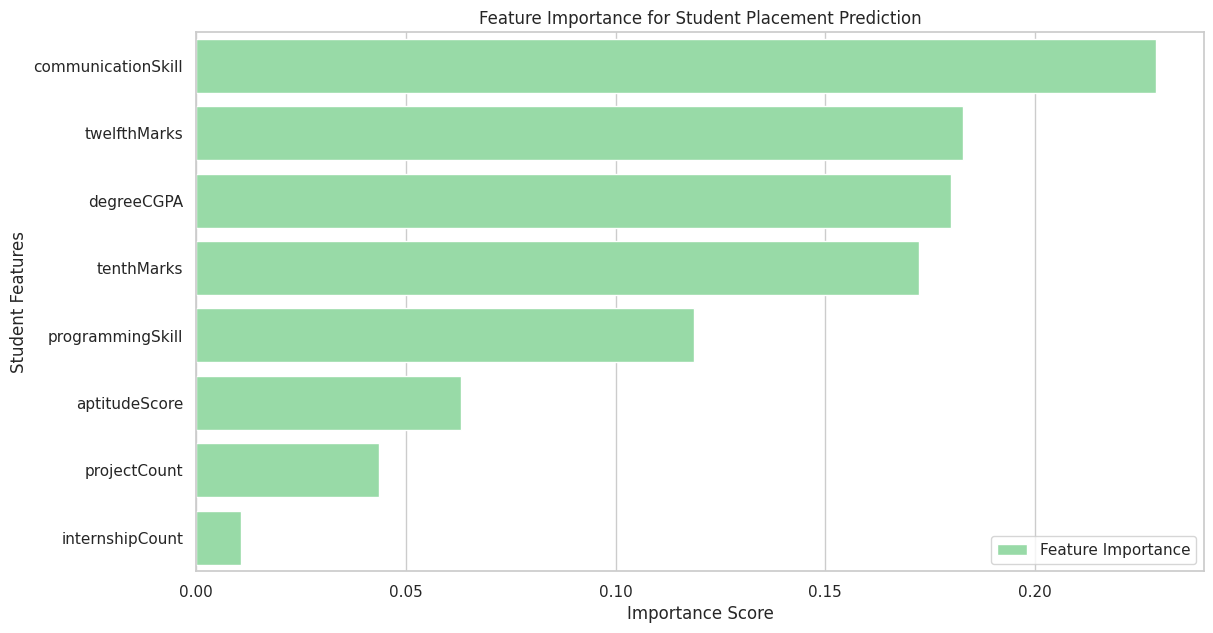

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(13, 7))

# Plot Feature Importance
sns.set_color_codes("pastel")

sns.barplot(
    x="importance",
    y="index",
    data=feature_importances,
    label="Feature Importance",
    color="g"
)

ax.set(
    xlabel="Importance Score",
    ylabel="Student Features",
    title="Feature Importance for Student Placement Prediction"
)

plt.show()

/tmp/ipykernel_474/1580146725.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


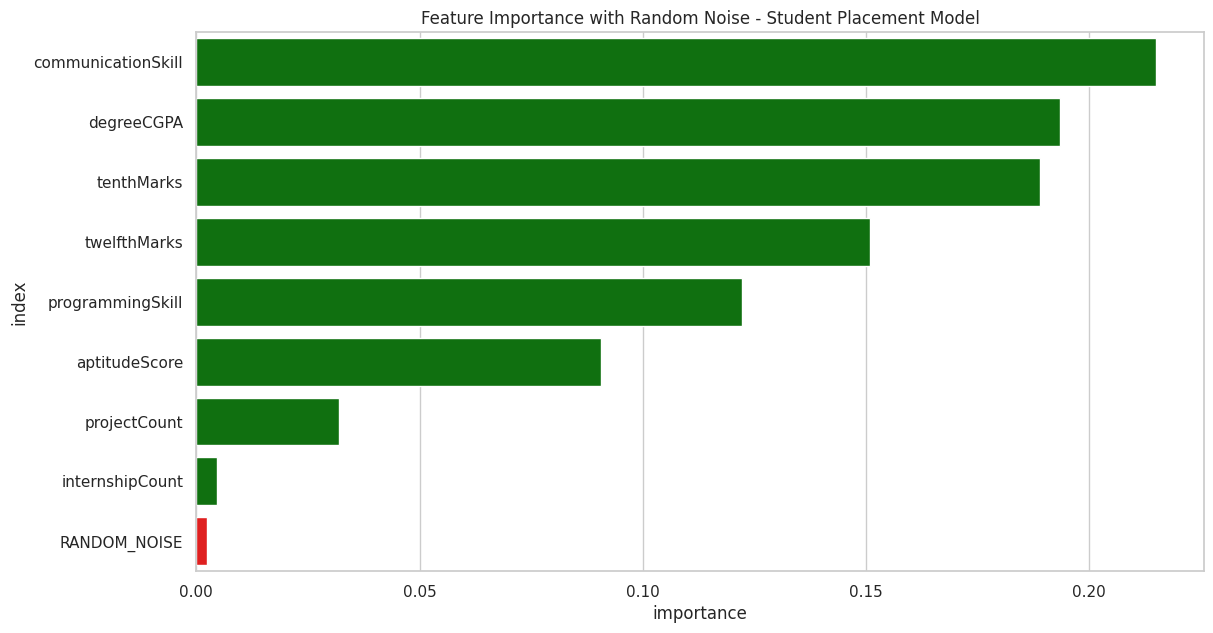

In [43]:
# Apply Random Noise to dataset
X_train_rnoise = pd.DataFrame(X_train)

# Add random noise column
X_train_rnoise['RANDOM_NOISE'] = np.random.normal(0, 1, X_train_rnoise.shape[0])


# Train Random Forest with noisy dataset
from sklearn.ensemble import RandomForestClassifier

rf_random = RandomForestClassifier(random_state=42)

rf_random = rf_random.fit(X_train_rnoise, y_train)


# Get Feature Importances
feature_importances_random = pd.DataFrame(
    rf_random.feature_importances_,
    index=X_train_rnoise.columns,
    columns=['importance']
).sort_values('importance', ascending=False)

feature_importances_random = feature_importances_random.reset_index()


# Plot Feature Importance
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

f, ax = plt.subplots(figsize=(13,7))

clrs = ['red' if feature == 'RANDOM_NOISE' else 'green'
        for feature in feature_importances_random['index']]

sns.barplot(
    x="importance",
    y="index",
    data=feature_importances_random,
    palette=clrs
)

plt.title("Feature Importance with Random Noise - Student Placement Model")

plt.show()

In [44]:
X_train_rnoise.head()

,tenthMarks,twelfthMarks,degreeCGPA,aptitudeScore,programmingSkill,communicationSkill,internshipCount,projectCount,RANDOM_NOISE
462,60,51,6.36,4,10,8,1,0,-1.586680
442,92,57,9.00,10,9,4,1,4,0.126981
90,91,82,9.99,9,10,10,3,3,-1.459680
366,61,45,8.61,8,6,6,2,3,0.313894
434,91,94,7.95,8,1,6,3,2,-1.701980


In [47]:
rf.predict_proba(X_test)[0:10]

array([[0.94, 0.06],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.99, 0.01],
       [0.  , 1.  ]])